## Imports

In [1]:
from gvxrPython3 import gvxr 
from gvxrPython3.utils import  loadSpekpySpectrum
import ipynbname
import os
import numpy as np
from PIL import Image
import sys

import matplotlib.pyplot as plt 
from pathlib import Path


path = ipynbname.path()
BASE = path.parents[2] 

sys.path.append(str(BASE))
from Classes.Nanotom_class.NanotomXCT import NanotomXCT
from Classes.Comparisor_class.xct_comparisor import *
path_data = BASE / "Data/Lego_minifigure"
path_results = BASE / "Results/Lego_minifigure"

if not os.path.exists(path_results):
    os.makedirs(path_results)


## Acquisition settings

In [2]:
SDD = 399.99865000 # Source-Detector distance 
SSD = 95.99990000 # Source-Sample distance 

voltage_kV = 60
current_mA = 0.3 
exposure_time_s = 0.375013 

# Number of detector pixels 
xPixels = 1300
yPixels = 2048
pixel_size = 0.1

scaling = 1
lenght_unit = "mm"

num_of_proj = 2042

tom = NanotomXCT(length_unit=lenght_unit, scaling=scaling, output_path=path_results)
tom.set_distances(SSD=SSD, SDD=SDD)
tom.setup_detector(xPixels=xPixels, yPixels=yPixels)
tom.setup_source(voltage_kV=voltage_kV, current_mA=current_mA, exposure_time_s=exposure_time_s, noise=True)

s = sp.Spek(kvp= 60 , th= 12 , mas= 0.11250389999999999 , z= 39.999864959716795
594511367.3923327  photons / cm^2
59451.13762512425  photons / pixel


## Loading meshes and applying material compositions

In [3]:
gvxr.removePolygonMeshesFromSceneGraph()
# Body
mixture_body, mf_body = ["C","H","N"], [0.871, 0.081, 0.048]
density_body = 1.04
path_STL_body_simpl = path_data / "Meshes/MeshBodyfastSimplified.stl"


# Hands 
mixture_hands, mf_hands = ["C", "H", "O"], [0.4, 0.067, 0.533]
density_hands = 1.41
path_STL_hands_simpl = path_data / "Meshes/Mesh from Hands fastsimplified.stl"


# Print
mixture_print, mf_print = ["Ti", "O", "C", "H"], [0.3, 0.27, 0.34, 0.04]
density_print = 0.6
path_STL_print_simpl = path_data / "Meshes/Mesh from Print fastsimplified.stl"


tom.addMesh(label="Body", path=path_STL_body_simpl, density=density_body, mixture= mixture_body, mass_fraction=mf_body)
tom.addMesh(label="Hands", path=path_STL_hands_simpl, density=density_hands, mixture=mixture_hands, mass_fraction=mf_hands)
tom.addMesh(label="Print", path=path_STL_print_simpl, density=density_body, mixture=mixture_body, mass_fraction=mf_body)
           

## Generating simulated projection and comparing to experimental projection

Mean value experimental: 0.9087641835212708
Mean value simulated: 0.9111411571502686
RMSE: 0.0112280985
SSIM: 0.861296468381183
HI: 0.8729469651442308


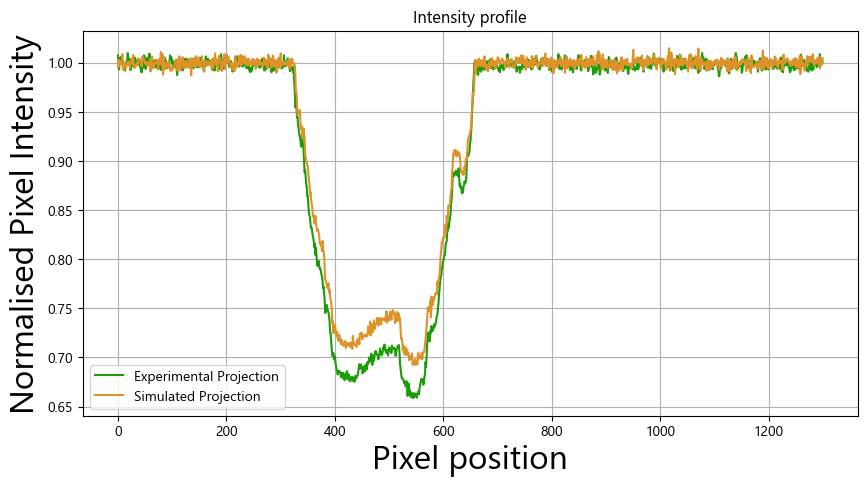

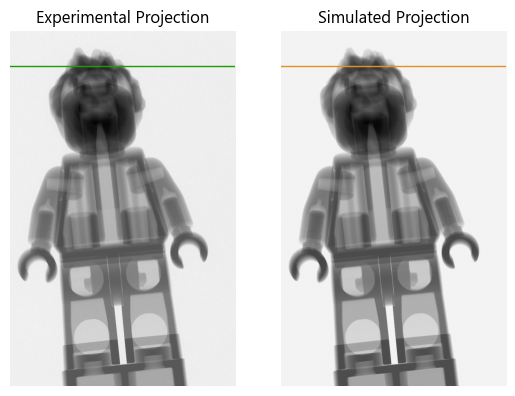

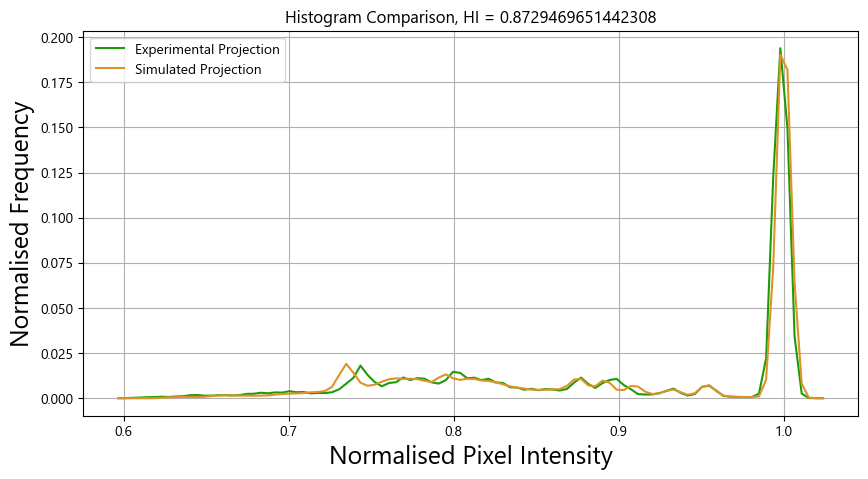

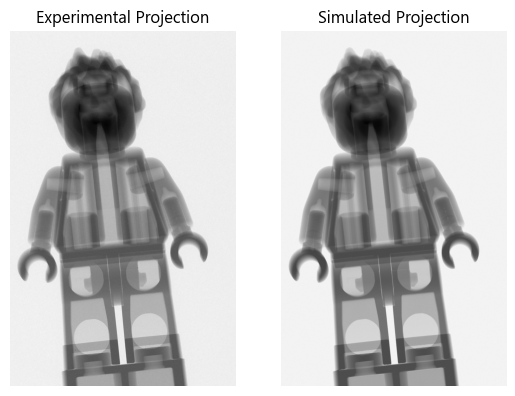

In [4]:
img_sim = tom.compute2D() 

img_org = get_org_projection(path_data/ f"Projections/260224 Lego man new00001.tif", flip=True)
white_value = img_org[:10,:].mean()
img_org /= white_value

print(f"Mean value experimental: {np.mean(img_org)}")
print(f"Mean value simulated: {np.mean(img_sim)}")

get_metrics(img_sim, img_org)
two_line_plot(img_sim, img_org, 200)
histogram_plot(img_sim, img_org)

plt.figure()
plt.subplot(1,2,1)
plt.imshow(img_org, cmap='gray')
plt.axis('off')
plt.title("Experimental Projection")

plt.subplot(1,2,2)
plt.imshow(img_sim, cmap='gray')
plt.axis('off')
plt.title("Simulated Projection")
plt.show()


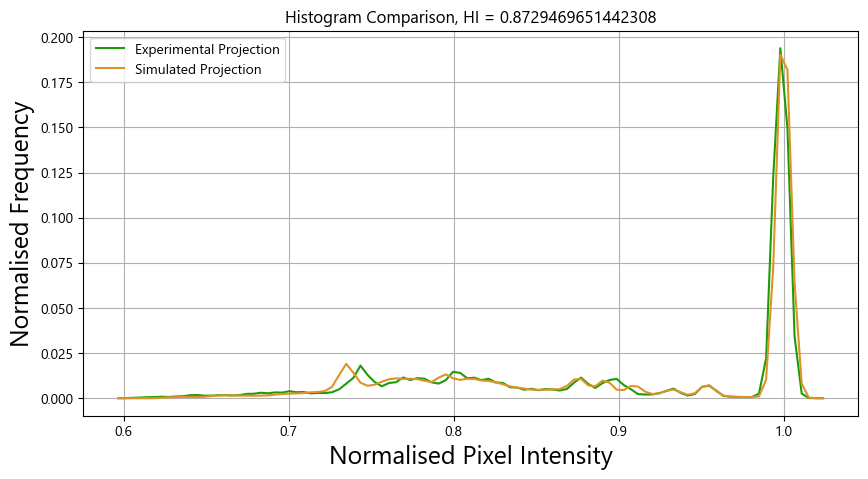

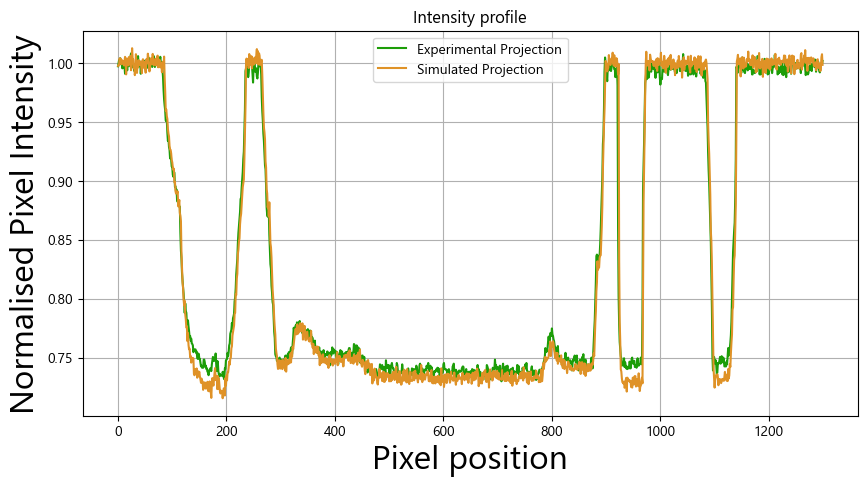

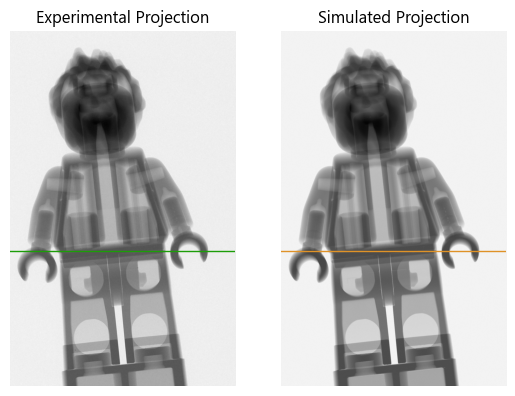

In [5]:
histogram_plot(img_sim, img_org)
two_line_plot(img_sim, img_org, 1270)

## Acquisition and Reconstruction

In [ ]:
filter = "ram-lak"
FCC = 0

In [ ]:
json = tom.computeCTAcquisition(num_of_proj, label="full_scale")

In [ ]:
recon = tom.computeReconstruction(tom.CT_path, json, filter=filter)

## Generating average metrics for multple projections

In [ ]:
def plot_abs_error(img_org, img_sim, idx):
    error = img_org-img_sim

    abs_err = np.abs(error)
    print(f"Max error: {(abs_err.max())}")

    vmin = np.percentile(abs_err, 1)
    vmax = np.percentile(abs_err, 99)

    plt.figure()
    im = plt.imshow(abs_err, cmap='magma', vmin=vmin, vmax=0.045)
    plt.axis('off')
    
    cbar = plt.colorbar(im)
    cbar.set_label("Absolute Error", rotation=270, labelpad=20, fontsize=18)

    plt.show()

In [ ]:
sum_hi = 0
sum_rmse = 0
path = "D:/x-ray_sim/Results/Legoman2/CT-Scans/CT_2042_full_scale_FFC=0"
real_projections_path = "D:/x-ray_sim/Data/Legoman2/Projections"

nbr = 20

for i in range(0,nbr,1):
    k = (i * int(2042/nbr))
    if k == 0:
        sim_proj = np.array(Image.open(path + f"/Projections/projection_000{k}.tiff"), dtype=np.single)/ gvxr.getTotalEnergyWithDetectorResponse()
    elif k <= 10:
        sim_proj = np.array(Image.open(path + f"/Projections/projection_000{k-1}.tiff"), dtype=np.single)/ gvxr.getTotalEnergyWithDetectorResponse()
    elif k <= 100:
        sim_proj = np.array(Image.open(path + f"/Projections/projection_00{k-1}.tiff"), dtype=np.single)/ gvxr.getTotalEnergyWithDetectorResponse()
    elif k <= 1000:
        sim_proj = np.array(Image.open(path + f"/Projections/projection_0{k-1}.tiff"), dtype=np.single)/ gvxr.getTotalEnergyWithDetectorResponse()
    else:
        sim_proj = np.array(Image.open(path + f"/Projections/projection_{k-1}.tiff"), dtype=np.single)/ gvxr.getTotalEnergyWithDetectorResponse()
    

    n = k
    if k == 0:
        n = k+1
        real_file = f"/260224 Lego man new0000{n}.tif"
    elif n < 10:
        real_file = f"/260224 Lego man new0000{n}.tif"
    elif n < 100:
        real_file = f"/260224 Lego man new000{n}.tif"
    elif n < 1000:
        real_file = f"/260224 Lego man new00{n}.tif"
    else:
        real_file = f"/260224 Lego man new0{n}.tif"

    real_proj = get_org_projection(real_projections_path + real_file, scaling=scaling, flip=True)
    white_value = real_proj[:10,:].mean()
    real_proj /= white_value
    sim_proj = sim_proj[:-100, :]
    real_proj = real_proj[:-100, :]
    images = {"Real Projection": real_proj,
          "Simulated Projection": sim_proj}
    
    print("----------------------------------")   
    print("Projection number: " + str(n))   
    print("Projection angle: " + str(i*360/nbr)) 
    # two_line_plot(sim_proj, real_proj, 250)
    plot_abs_error(real_proj, sim_proj,i+1)
    sum_hi += hi(real_proj, sim_proj)
    sum_rmse += rmse(real_proj, sim_proj)
    #get_metrics(real_proj, sim_proj, "")
    print("----------------------------------")   

print("Average HI = " + str(sum_hi/nbr))
print("Average RMSE = " + str(sum_rmse/nbr))